**Generate Karman-Trefftz airfoils**


---
*using
ε=0.08
β=0.07
τ=0.2*



Computed Cl = 0.48824646405112937


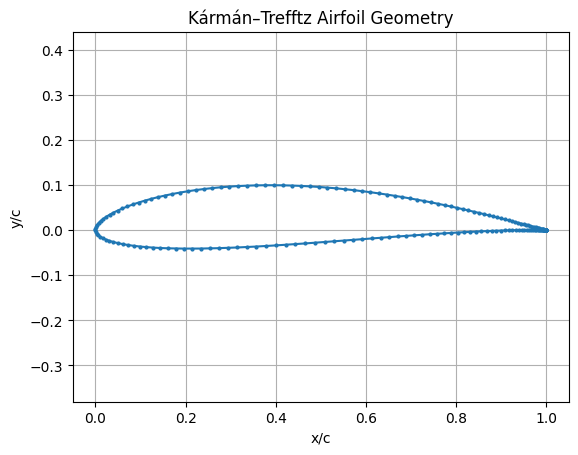

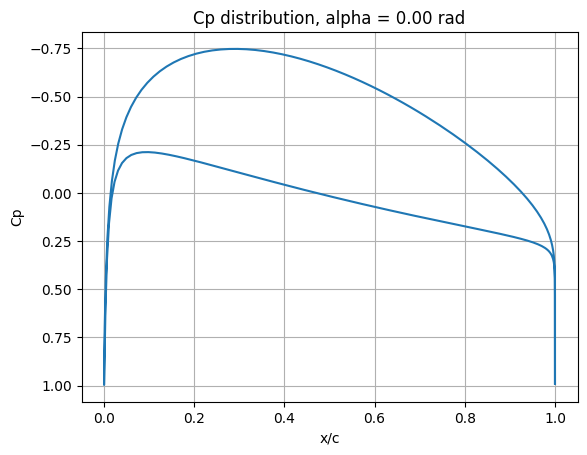

Saved XFOIL coordinates to KT_eps0p08_beta0p07_tau0p2.dat


In [4]:
import numpy as np

def ktreff(alpha,eps,beta,tau,n):
      '''
      Karman-Trefftz airfoils (c) N.D.Sandham 2006
      inputs:  alpha=incidence, eps=thickness factor, beta=camber factor,
      tau=trailing edge angle, n=number of points
      outputs: x,y: airfoil coordinates, Cp: pressure distribution
      Cl: lift coefficient

      '''

      #first define i=sqrt(-1) and parameters p,a(circle radius) and b
      pi=np.pi
      i=complex(0.0,1.0)
      p=2.0-tau/pi
      b=0.25*((1.0+eps)**p-eps**p)/(1.0+eps)**p
      a=b*(1.0+eps)/np.cos(beta)

      # use a cosine mapping to put more points near both leading and trailing
      # edge regions
      lis = np.append(np.arange(0,1,1/n),1)
      theta=2.0*pi-beta-pi*(1.0-np.cos(pi*lis))

      '''
      # alternative 1: Uniformly distributed theta
      lis = np.append(np.arange(0,1,1/n),1)
      theta=2.0*pi-beta-2.0*pi*lis;

      # alternative 2: Top/Bottom independent cosine distributions, more points at the trailing edge
      m=np.round((n/2),2)
      theta = np.zeros(int(n))
      theta[int(0.0):int(m)]=2.0*pi-beta-0.5*(pi-2*beta)*(1.0-np.cos(pi*np.arange(0, 1, 1.0/m)))
      theta[int(m):int(n+1)]=pi+beta-0.5*(pi+2*beta)*(1.0-np.cos(pi* np.arange(0, 1, 1.0/m)))
      # transform the circle to get the airfoil geometry (shifted so that 0<x<1)
      '''

      zbar=a*np.cos(theta)-b*eps+i*(a*np.sin(theta)+a*np.sin(beta))
      zp=(zbar+b)**p
      zm=(zbar-b)**p
      z=2.0*b*(zp+zm)/(zp-zm)
      dzdzbar=(8.0*b**2*p*(zp*zm))/((zbar**2-b**2)*(zp-zm)**2)
      x=z.real+1.0-2.0*b
      y=z.imag

      # now transform the flow
      dphidzbar=np.exp(-i*alpha)*(1.0-np.exp(i*2.0*(alpha-theta)))+i*2.0*np.sin(alpha+beta)*np.exp(-i*theta)
      dphidz=dphidzbar/dzdzbar
      Uinf=p/2.0
      Cp = 1.0-dphidz*dphidz.conjugate()/Uinf**2
      Cl = 8.0*pi*a*np.sin(alpha+beta)/Uinf

      return x, y, Cp, Cl

if __name__ == "__main__":
    import numpy as np
    import matplotlib.pyplot as plt

    # --- INPUTS (from your coursework) ---
    alpha = 0.0      # incidence [radians] for this run (0 for pure geometry)
    eps   = 0.08     # thickness factor ε
    beta  = 0.07     # camber factor β  (radians)
    tau   = 0.2      # trailing edge angle τ (radians)
    n     = 200      # number of points along the surface

    # --- CALL KARMAN–TREFFTZ GENERATOR ---
    x, y, Cp, Cl = ktreff(alpha, eps, beta, tau, n)
    print("Computed Cl =", Cl.real)

    # --- GEOMETRY PLOT ---
    plt.figure()
    plt.plot(x, y, '-o', markersize=2)
    plt.axis('equal')
    plt.xlabel('x/c')
    plt.ylabel('y/c')
    plt.title('Kármán–Trefftz Airfoil Geometry')
    plt.grid(True)

    # --- Cp PLOT ---
    plt.figure()
    plt.plot(x, Cp.real)
    plt.gca().invert_yaxis()  # conventional Cp plot
    plt.xlabel('x/c')
    plt.ylabel('Cp')
    plt.title(f'Cp distribution, alpha = {alpha:.2f} rad')
    plt.grid(True)

    plt.show()

    # --- SAVE XFOIL .dat FILE (x, y) ---
    coords = np.column_stack((x, y))
    filename = "KT_eps0p08_beta0p07_tau0p2.dat"
    with open(filename, "w") as f:
        f.write("KTreff_eps0.08_beta0.07_tau0.2\n")  # airfoil name line for XFOIL
        np.savetxt(f, coords, fmt="%.6f")

    print(f"Saved XFOIL coordinates to {filename}")


**Convert to nearest NACA 4-digit airfoil**

In [5]:
import numpy as np

# ------------------------------------------------------------------
# 1) Load KT airfoil coordinates exported earlier (XFOIL .dat file)
# ------------------------------------------------------------------
# First line is a title, so skip it
data = np.loadtxt("KT_eps0p08_beta0p07_tau0p2.dat", skiprows=1)
x_raw = data[:, 0]
y_raw = data[:, 1]

# ------------------------------------------------------------------
# 2) Split into upper and lower surfaces and sort by x
# ------------------------------------------------------------------
upper_mask = y_raw >= 0.0
lower_mask = y_raw <= 0.0

x_u, y_u = x_raw[upper_mask], y_raw[upper_mask]
x_l, y_l = x_raw[lower_mask], y_raw[lower_mask]

# sort each surface by x (increasing)
order_u = np.argsort(x_u)
order_l = np.argsort(x_l)

x_u, y_u = x_u[order_u], y_u[order_u]
x_l, y_l = x_l[order_l], y_l[order_l]

# ------------------------------------------------------------------
# 3) Interpolate both surfaces onto a common chordwise grid
# ------------------------------------------------------------------
x_c = np.linspace(0.0, 1.0, 400)          # common x/c grid
y_u_i = np.interp(x_c, x_u, y_u)          # upper surface y(x)
y_l_i = np.interp(x_c, x_l, y_l)          # lower surface y(x)

# ------------------------------------------------------------------
# 4) Camber line and thickness normal to camber line
# ------------------------------------------------------------------
# camber line
y_c = 0.5 * (y_u_i + y_l_i)

# slope dyc/dx (for camber line)
dyc_dx = np.gradient(y_c, x_c)

# thickness defined as distance between surfaces along
# the normal to the camber line:
# t_n(x) = (y_u - y_l) / sqrt(1 + (dyc/dx)^2)
delta_y = y_u_i - y_l_i
t_normal = delta_y / np.sqrt(1.0 + dyc_dx**2)

# ------------------------------------------------------------------
# 5) Extract max camber, its position, and max thickness
# ------------------------------------------------------------------
# max camber
camber_max = np.max(y_c)
i_cmax = np.argmax(y_c)
x_cmax = x_c[i_cmax]

# max thickness (normal to camber)
t_max = np.max(t_normal)
i_tmax = np.argmax(t_normal)
x_tmax = x_c[i_tmax]

print("---- KT airfoil geometric parameters ----")
print(f"Max camber m       = {camber_max:.5f} (fraction of chord)")
print(f"Location x_m/c     = {x_cmax:.5f}")
print(f"Max thickness t/c  = {t_max:.5f} (normal to camber line)")
print(f"Location x_t/c     = {x_tmax:.5f}")

# ------------------------------------------------------------------
# 6) Convert to nearest NACA 4-digit airfoil
# ------------------------------------------------------------------
# NACA 4-digit uses:
#   M = max camber (%)      -> first digit
#   P = position (tenths c) -> second digit
#   TT = thickness (%)      -> last two digits

M  = int(round(camber_max * 100))   # percent camber
P  = int(round(x_cmax * 10))        # tenths of chord
TT = int(round(t_max * 100))        # percent thickness

# clamp to valid ranges
M  = max(0, min(M, 9))
P  = max(0, min(P, 9))
TT = max(1, min(TT, 99))

print("\n---- Nearest NACA 4-digit estimate ----")
print(f"Approximate NACA 4-digit airfoil: NACA {M}{P}{TT:02d}")


---- KT airfoil geometric parameters ----
Max camber m       = 0.03422 (fraction of chord)
Location x_m/c     = 0.49624
Max thickness t/c  = 0.13595 (normal to camber line)
Location x_t/c     = 0.33584

---- Nearest NACA 4-digit estimate ----
Approximate NACA 4-digit airfoil: NACA 3514


**Plot KT vs NACA**

KT camber & thickness (normal to camber line):
  Max camber m      = 0.03422
  Position x_m/c    = 0.49624
  Max thickness t/c = 0.13595
  Position x_t/c    = 0.33584

Nearest NACA 4-digit ≈ NACA 3514


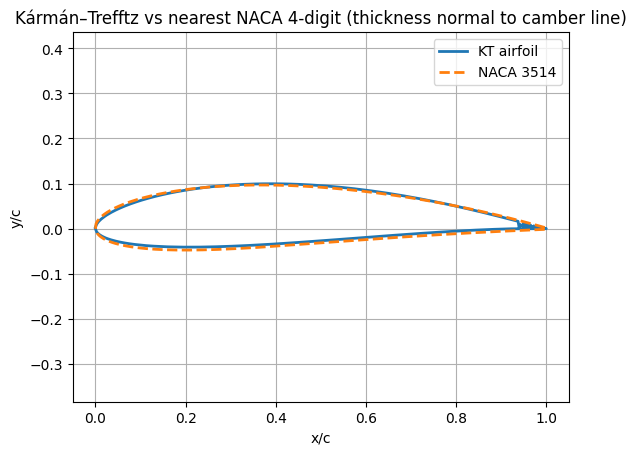

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1) Load KT airfoil coordinates (same .dat you generated)
# ----------------------------------------------------------
data = np.loadtxt("KT_eps0p08_beta0p07_tau0p2.dat", skiprows=1)
x_raw = data[:, 0]
y_raw = data[:, 1]

# ----------------------------------------------------------
# 2) Split KT into upper/lower surfaces & sort by x
# ----------------------------------------------------------
upper_mask = y_raw >= 0.0
lower_mask = y_raw <= 0.0

x_u, y_u = x_raw[upper_mask], y_raw[upper_mask]
x_l, y_l = x_raw[lower_mask], y_raw[lower_mask]

order_u = np.argsort(x_u)
order_l = np.argsort(x_l)

x_u, y_u = x_u[order_u], y_u[order_u]
x_l, y_l = x_l[order_l], y_l[order_l]

# ----------------------------------------------------------
# 3) Interpolate both surfaces onto common x-grid
# ----------------------------------------------------------
x_c = np.linspace(0.0, 1.0, 400)      # common chordwise grid
y_u_i = np.interp(x_c, x_u, y_u)      # KT upper surface on x_c
y_l_i = np.interp(x_c, x_l, y_l)      # KT lower surface on x_c

# ----------------------------------------------------------
# 4) Camber & thickness NORMAL to camber line (KT)
# ----------------------------------------------------------
y_c = 0.5 * (y_u_i + y_l_i)           # camber line
dyc_dx = np.gradient(y_c, x_c)        # camber line slope

delta_y = y_u_i - y_l_i               # vertical distance
t_normal = delta_y / np.sqrt(1.0 + dyc_dx**2)  # normal thickness

# geometric parameters
camber_max = np.max(y_c)
x_cmax = x_c[np.argmax(y_c)]
t_max = np.max(t_normal)
x_tmax = x_c[np.argmax(t_normal)]

print("KT camber & thickness (normal to camber line):")
print(f"  Max camber m      = {camber_max:.5f}")
print(f"  Position x_m/c    = {x_cmax:.5f}")
print(f"  Max thickness t/c = {t_max:.5f}")
print(f"  Position x_t/c    = {x_tmax:.5f}")

# ----------------------------------------------------------
# 5) Nearest NACA 4-digit parameters
# ----------------------------------------------------------
M  = int(round(camber_max * 100))   # % camber
P  = int(round(x_cmax * 10))        # tenths of chord
TT = int(round(t_max * 100))        # % thickness

# clamp to valid ranges
M  = max(0, min(M, 9))
P  = max(0, min(P, 9))
TT = max(1, min(TT, 99))

print(f"\nNearest NACA 4-digit ≈ NACA {M}{P}{TT:02d}")

# ----------------------------------------------------------
# 6) NACA 4-digit generator (thickness normal to camber line)
# ----------------------------------------------------------
def naca4_geometry(M, P, TT, x):
    """
    Generate NACA 4-digit airfoil coordinates on x (0..1).
    Geometry constructed by adding thickness normal to camber line.
    """
    m = M / 100.0           # max camber
    p = P / 10.0            # position of max camber
    t = TT / 100.0          # thickness

    # Thickness distribution (standard NACA)
    a0, a1, a2, a3, a4 = 0.2969, -0.1260, -0.3516, 0.2843, -0.1015
    yt = 5 * t * (a0*np.sqrt(x) + a1*x + a2*x**2 + a3*x**3 + a4*x**4)

    # Camber line & slope
    yc = np.zeros_like(x)
    dyc_dx = np.zeros_like(x)

    if m > 0 and p > 0:
        idx1 = x < p
        idx2 = x >= p

        yc[idx1] = m / p**2 * (2*p*x[idx1] - x[idx1]**2)
        dyc_dx[idx1] = 2*m / p**2 * (p - x[idx1])

        yc[idx2] = m / (1 - p)**2 * ((1 - 2*p) + 2*p*x[idx2] - x[idx2]**2)
        dyc_dx[idx2] = 2*m / (1 - p)**2 * (p - x[idx2])

    # angle of camber line
    theta = np.arctan(dyc_dx)

    # add thickness NORMAL to camber line
    xu = x - yt*np.sin(theta)
    yu = yc + yt*np.cos(theta)
    xl = x + yt*np.sin(theta)
    yl = yc - yt*np.cos(theta)

    return xu, yu, xl, yl

# generate NACA geometry on same x-grid
xu_naca, yu_naca, xl_naca, yl_naca = naca4_geometry(M, P, TT, x_c)

# construct closed loops for plotting
x_kt_loop = np.concatenate([x_c, x_c[::-1]])
y_kt_loop = np.concatenate([y_u_i, y_l_i[::-1]])

x_naca_loop = np.concatenate([xu_naca, xl_naca[::-1]])
y_naca_loop = np.concatenate([yu_naca, yl_naca[::-1]])

# ----------------------------------------------------------
# 7) Plot KT vs NACA on the same graph
# ----------------------------------------------------------
plt.figure()
plt.plot(x_kt_loop, y_kt_loop, label="KT airfoil", linewidth=2)
plt.plot(x_naca_loop, y_naca_loop, "--", label=f"NACA {M}{P}{TT:02d}", linewidth=2)
plt.axis("equal")
plt.xlabel("x/c")
plt.ylabel("y/c")
plt.title("Kármán–Trefftz vs nearest NACA 4-digit (thickness normal to camber line)")
plt.grid(True)
plt.legend()
plt.show()


**Effect of Kármán–Trefftz Parameters**
(ε and β)
**on Airfoil Geometry**

/tmp/ipython-input-662909288.py:36: RuntimeWarning: invalid value encountered in divide
  dzdzbar = (8.0*b**2*p*(zp*zm))/((zbar**2 - b**2)*(zp - zm)**2)
/tmp/ipython-input-662909288.py:44: RuntimeWarning: invalid value encountered in divide
  dphidz = dphidzbar / dzdzbar


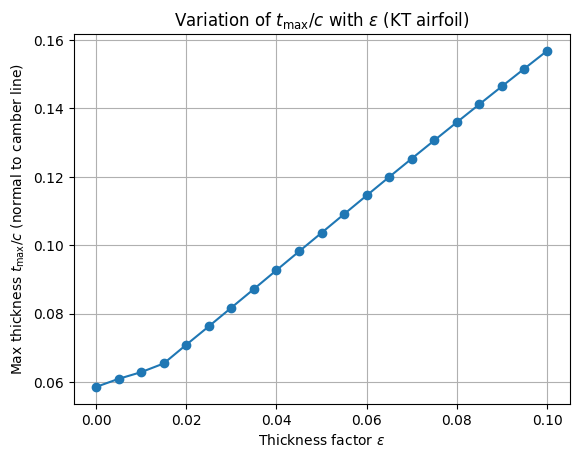

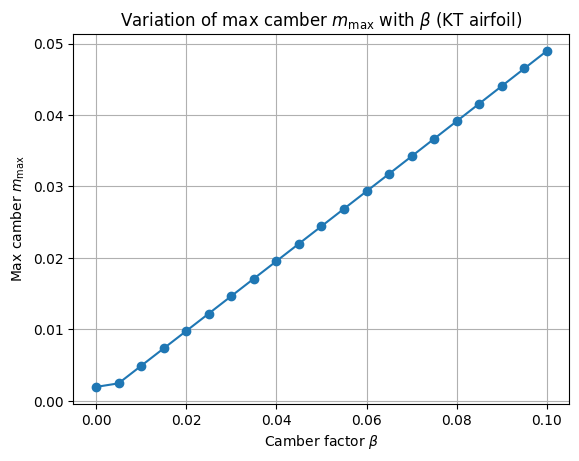

For your aerofoil (eps = 0.08, beta = 0.07):
  t_max/c ≈ 0.13595
  m_max   ≈ 0.03422


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1) Kármán–Trefftz airfoil generator (from ktreff.py)
# ==========================================================
def ktreff(alpha, eps, beta, tau, n):
    """
    Karman-Trefftz airfoils (c) N.D. Sandham 2006
    inputs:
      alpha = incidence (radians)
      eps   = thickness factor
      beta  = camber factor (radians)
      tau   = trailing edge angle (radians)
      n     = number of points
    outputs:
      x, y : airfoil coordinates
      Cp   : pressure distribution
      Cl   : lift coefficient
    """
    pi = np.pi
    i = complex(0.0, 1.0)
    p = 2.0 - tau/pi
    b = 0.25 * ((1.0 + eps)**p - eps**p) / (1.0 + eps)**p
    a = b * (1.0 + eps) / np.cos(beta)

    # cosine distribution in theta (more points near LE & TE)
    lis = np.append(np.arange(0, 1, 1/n), 1)
    theta = 2.0*pi - beta - pi*(1.0 - np.cos(pi*lis))

    # circle → KT transformation
    zbar = a*np.cos(theta) - b*eps + i*(a*np.sin(theta) + a*np.sin(beta))
    zp = (zbar + b)**p
    zm = (zbar - b)**p
    z = 2.0*b*(zp + zm)/(zp - zm)
    dzdzbar = (8.0*b**2*p*(zp*zm))/((zbar**2 - b**2)*(zp - zm)**2)

    x = z.real + 1.0 - 2.0*b   # shift so 0 < x < 1
    y = z.imag

    # flow transformation
    dphidzbar = (np.exp(-i*alpha)*(1.0 - np.exp(i*2.0*(alpha - theta)))
                 + i*2.0*np.sin(alpha + beta)*np.exp(-i*theta))
    dphidz = dphidzbar / dzdzbar
    Uinf = p/2.0
    Cp = 1.0 - dphidz * dphidz.conjugate() / Uinf**2
    Cl = 8.0*pi*a*np.sin(alpha + beta)/Uinf

    return x, y, Cp, Cl


# ==========================================================
# 2) Helper: camber & thickness (normal to camber line)
# ==========================================================
def camber_thickness_from_xy(x_raw, y_raw, n_grid=400):
    """
    From raw KT x,y points:
      - builds upper & lower surfaces
      - interpolates onto uniform x grid
      - computes camber line
      - computes thickness measured NORMAL to camber line
    Returns:
      camber_max, t_max
    """
    # split into upper/lower by sign of y
    upper_mask = y_raw >= 0.0
    lower_mask = y_raw <= 0.0

    x_u, y_u = x_raw[upper_mask], y_raw[upper_mask]
    x_l, y_l = x_raw[lower_mask], y_raw[lower_mask]

    # sort both surfaces by x
    order_u = np.argsort(x_u)
    order_l = np.argsort(x_l)

    x_u, y_u = x_u[order_u], y_u[order_u]
    x_l, y_l = x_l[order_l], y_l[order_l]

    # interpolate onto common x-grid
    x_c = np.linspace(0.0, 1.0, n_grid)
    y_u_i = np.interp(x_c, x_u, y_u)
    y_l_i = np.interp(x_c, x_l, y_l)

    # camber line and slope
    y_c = 0.5 * (y_u_i + y_l_i)
    dyc_dx = np.gradient(y_c, x_c)

    # thickness measured along normal to camber line
    delta_y = y_u_i - y_l_i
    t_normal = delta_y / np.sqrt(1.0 + dyc_dx**2)

    camber_max = np.max(y_c)
    t_max = np.max(t_normal)
    return camber_max, t_max


# ==========================================================
# 3) Parameter sweeps: vary eps and beta separately
# ==========================================================
alpha = 0.0       # geometry only (radians)
eps_fixed = 0.08  # your base thickness factor
beta_fixed = 0.07 # your base camber factor (radians)
tau_fixed = 0.2   # trailing-edge angle (radians)
n_pts = 200       # number of points on circle/airfoil

# ---- 3a) Vary epsilon, keep beta and tau fixed ----
eps_vals = np.linspace(0.0, 0.10, 21)
camber_eps = []
thick_eps = []

for eps in eps_vals:
    x, y, Cp, Cl = ktreff(alpha, eps, beta_fixed, tau_fixed, n_pts)
    m_max, t_max = camber_thickness_from_xy(x, y)
    camber_eps.append(m_max)
    thick_eps.append(t_max)

camber_eps = np.array(camber_eps)
thick_eps = np.array(thick_eps)

# ---- 3b) Vary beta, keep eps and tau fixed ----
beta_vals = np.linspace(0.0, 0.10, 21)
camber_beta = []
thick_beta = []

for beta in beta_vals:
    x, y, Cp, Cl = ktreff(alpha, eps_fixed, beta, tau_fixed, n_pts)
    m_max, t_max = camber_thickness_from_xy(x, y)
    camber_beta.append(m_max)
    thick_beta.append(t_max)

camber_beta = np.array(camber_beta)
thick_beta = np.array(thick_beta)

# ==========================================================
# 4) Plots: t_max vs eps, and m_max vs beta
# ==========================================================

# Max thickness vs epsilon
plt.figure()
plt.plot(eps_vals, thick_eps, "-o")
plt.xlabel(r"Thickness factor $\epsilon$")
plt.ylabel(r"Max thickness $t_{\max}/c$ (normal to camber line)")
plt.title(r"Variation of $t_{\max}/c$ with $\epsilon$ (KT airfoil)")
plt.grid(True)

# Max camber vs beta
plt.figure()
plt.plot(beta_vals, camber_beta, "-o")
plt.xlabel(r"Camber factor $\beta$")
plt.ylabel(r"Max camber $m_{\max}$")
plt.title(r"Variation of max camber $m_{\max}$ with $\beta$ (KT airfoil)")
plt.grid(True)

plt.show()

# Optional: print values at your aerofoil parameters
i_eps = np.argmin(np.abs(eps_vals - eps_fixed))
i_beta = np.argmin(np.abs(beta_vals - beta_fixed))
print("For your aerofoil (eps = 0.08, beta = 0.07):")
print(f"  t_max/c ≈ {thick_eps[i_eps]:.5f}")
print(f"  m_max   ≈ {camber_beta[i_beta]:.5f}")


/tmp/ipython-input-2067515950.py:36: RuntimeWarning: invalid value encountered in divide
  dzdzbar = (8.0*b**2*p*(zp*zm))/((zbar**2 - b**2)*(zp - zm)**2)
/tmp/ipython-input-2067515950.py:44: RuntimeWarning: invalid value encountered in divide
  dphidz = dphidzbar / dzdzbar


For your aerofoil (eps = 0.08, beta = 0.07):
  t_max/c ≈ 0.13595
  m_max   ≈ 0.03422
  dt_max/deps ≈ 1.056
  dm_max/dbeta ≈ 0.491


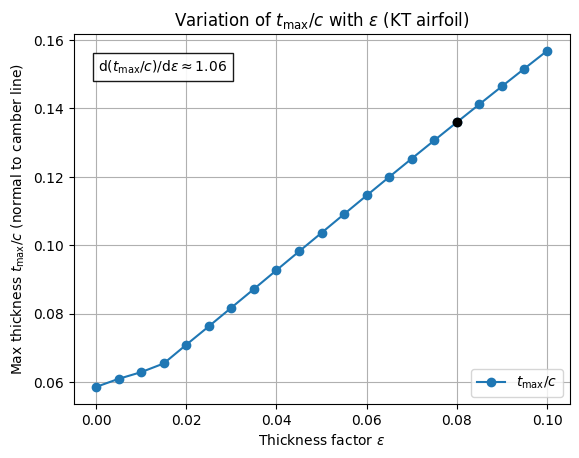

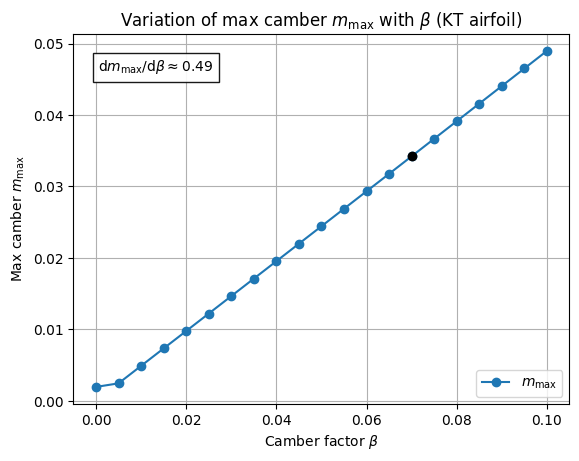

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1) Kármán–Trefftz airfoil generator
# ==========================================================
def ktreff(alpha, eps, beta, tau, n):
    """
    Karman-Trefftz airfoils (c) N.D. Sandham 2006
    inputs:
      alpha = incidence (radians)
      eps   = thickness factor
      beta  = camber factor (radians)
      tau   = trailing edge angle (radians)
      n     = number of points
    outputs:
      x, y : airfoil coordinates
      Cp   : pressure distribution
      Cl   : lift coefficient
    """
    pi = np.pi
    i = complex(0.0, 1.0)
    p = 2.0 - tau/pi
    b = 0.25 * ((1.0 + eps)**p - eps**p) / (1.0 + eps)**p
    a = b * (1.0 + eps) / np.cos(beta)

    # cosine distribution in theta (more points near LE & TE)
    lis = np.append(np.arange(0, 1, 1/n), 1)
    theta = 2.0*pi - beta - pi*(1.0 - np.cos(pi*lis))

    # circle → KT transformation
    zbar = a*np.cos(theta) - b*eps + i*(a*np.sin(theta) + a*np.sin(beta))
    zp = (zbar + b)**p
    zm = (zbar - b)**p
    z = 2.0*b*(zp + zm)/(zp - zm)
    dzdzbar = (8.0*b**2*p*(zp*zm))/((zbar**2 - b**2)*(zp - zm)**2)

    x = z.real + 1.0 - 2.0*b   # shift so 0 < x < 1
    y = z.imag

    # flow transformation
    dphidzbar = (np.exp(-i*alpha)*(1.0 - np.exp(i*2.0*(alpha - theta)))
                 + i*2.0*np.sin(alpha + beta)*np.exp(-i*theta))
    dphidz = dphidzbar / dzdzbar
    Uinf = p/2.0
    Cp = 1.0 - dphidz * dphidz.conjugate() / Uinf**2
    Cl = 8.0*pi*a*np.sin(alpha + beta)/Uinf

    return x, y, Cp, Cl


# ==========================================================
# 2) Helper: camber & thickness (normal to camber line)
# ==========================================================
def camber_thickness_from_xy(x_raw, y_raw, n_grid=400):
    """
    From raw KT x,y points:
      - builds upper & lower surfaces
      - interpolates onto uniform x grid
      - computes camber line
      - computes thickness measured NORMAL to camber line
    Returns:
      camber_max, t_max
    """
    # split into upper/lower by sign of y
    upper_mask = y_raw >= 0.0
    lower_mask = y_raw <= 0.0

    x_u, y_u = x_raw[upper_mask], y_raw[upper_mask]
    x_l, y_l = x_raw[lower_mask], y_raw[lower_mask]

    # sort both surfaces by x
    order_u = np.argsort(x_u)
    order_l = np.argsort(x_l)

    x_u, y_u = x_u[order_u], y_u[order_u]
    x_l, y_l = x_l[order_l], y_l[order_l]

    # interpolate onto common x-grid
    x_c = np.linspace(0.0, 1.0, n_grid)
    y_u_i = np.interp(x_c, x_u, y_u)
    y_l_i = np.interp(x_c, x_l, y_l)

    # camber line and slope
    y_c = 0.5 * (y_u_i + y_l_i)
    dyc_dx = np.gradient(y_c, x_c)

    # thickness measured along normal to camber line
    delta_y = y_u_i - y_l_i
    t_normal = delta_y / np.sqrt(1.0 + dyc_dx**2)

    camber_max = np.max(y_c)
    t_max = np.max(t_normal)
    return camber_max, t_max


# ==========================================================
# 3) Parameter sweeps: vary eps and beta separately
# ==========================================================
alpha = 0.0       # geometry only (radians)
eps_fixed = 0.08  # your base thickness factor
beta_fixed = 0.07 # your base camber factor (radians)
tau_fixed = 0.2   # trailing-edge angle (radians)
n_pts = 200       # number of points on circle/airfoil

# ---- 3a) Vary epsilon, keep beta and tau fixed ----
eps_vals = np.linspace(0.0, 0.10, 21)
camber_eps = []
thick_eps = []

for eps in eps_vals:
    x, y, Cp, Cl = ktreff(alpha, eps, beta_fixed, tau_fixed, n_pts)
    m_max, t_max = camber_thickness_from_xy(x, y)
    camber_eps.append(m_max)
    thick_eps.append(t_max)

camber_eps = np.array(camber_eps)
thick_eps = np.array(thick_eps)

# ---- 3b) Vary beta, keep eps and tau fixed ----
beta_vals = np.linspace(0.0, 0.10, 21)
camber_beta = []
thick_beta = []

for beta in beta_vals:
    x, y, Cp, Cl = ktreff(alpha, eps_fixed, beta, tau_fixed, n_pts)
    m_max, t_max = camber_thickness_from_xy(x, y)
    camber_beta.append(m_max)
    thick_beta.append(t_max)

camber_beta = np.array(camber_beta)
thick_beta = np.array(thick_beta)

# ---- 3c) Gradients at your aerofoil values ----
i_eps = np.argmin(np.abs(eps_vals - eps_fixed))
i_beta = np.argmin(np.abs(beta_vals - beta_fixed))

grad_thick_eps = np.gradient(thick_eps, eps_vals)
grad_camber_beta = np.gradient(camber_beta, beta_vals)

slope_t_at_eps = grad_thick_eps[i_eps]       # dt_max/deps at eps_fixed
slope_m_at_beta = grad_camber_beta[i_beta]   # dm_max/dbeta at beta_fixed

print("For your aerofoil (eps = 0.08, beta = 0.07):")
print(f"  t_max/c ≈ {thick_eps[i_eps]:.5f}")
print(f"  m_max   ≈ {camber_beta[i_beta]:.5f}")
print(f"  dt_max/deps ≈ {slope_t_at_eps:.3f}")
print(f"  dm_max/dbeta ≈ {slope_m_at_beta:.3f}")

# ==========================================================
# 4) Plots with fixed annotation placement
# ==========================================================

# ---- Max thickness vs epsilon ----
plt.figure()
plt.plot(eps_vals, thick_eps, "-o", label=r"$t_{\max}/c$")
plt.scatter(eps_fixed, thick_eps[i_eps], color="black", zorder=5)

plt.xlabel(r"Thickness factor $\epsilon$")
plt.ylabel(r"Max thickness $t_{\max}/c$ (normal to camber line)")
plt.title(r"Variation of $t_{\max}/c$ with $\epsilon$ (KT airfoil)")
plt.grid(True)
plt.legend()

# Gradient annotation (top-left, axes-relative)
plt.text(
    0.05, 0.90,
    rf"$\mathrm{{d}}(t_{{\max}}/c)/\mathrm{{d}}\epsilon \approx {slope_t_at_eps:.2f}$",
    transform=plt.gca().transAxes,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.9)
)

plt.show()


# ---- Max camber vs beta ----
plt.figure()
plt.plot(beta_vals, camber_beta, "-o", label=r"$m_{\max}$")
plt.scatter(beta_fixed, camber_beta[i_beta], color="black", zorder=5)

plt.xlabel(r"Camber factor $\beta$")
plt.ylabel(r"Max camber $m_{\max}$")
plt.title(r"Variation of max camber $m_{\max}$ with $\beta$ (KT airfoil)")
plt.grid(True)
plt.legend()

# Gradient annotation (top-left, axes-relative)
plt.text(
    0.05, 0.90,
    rf"$\mathrm{{d}}m_{{\max}}/\mathrm{{d}}\beta \approx {slope_m_at_beta:.2f}$",
    transform=plt.gca().transAxes,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.9)
)

plt.show()



**Doublet panel method accuracy vs “exact” KT CL**


Exact (conformal mapping) Cl at 3.0°: 0.852022

Panel method results at alpha = 3°:
  N =  20 panels:   Cl_panel = 0.790905,  |error| = 6.112e-02
  N =  40 panels:   Cl_panel = 0.818111,  |error| = 3.391e-02
  N =  80 panels:   Cl_panel = 0.834362,  |error| = 1.766e-02
  N = 160 panels:   Cl_panel = 0.843260,  |error| = 8.761e-03
  N = 320 panels:   Cl_panel = 0.847675,  |error| = 4.346e-03

Estimated order of accuracy p ≈ 0.96


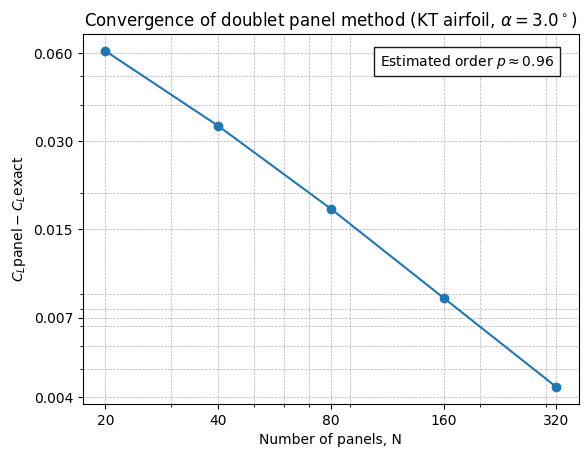

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# Make sure Colab can see dpan.py
sys.path.append("/content")
from dpan import dpan   # provided doublet panel method

# ----------------------------------------------------------
# Helper: resample closed KT airfoil onto N_panels
# ----------------------------------------------------------
def resample_closed_curve(x, y, N_panels):
    """
    Resample a closed curve (x,y) to N_panels panels (N_panels+1 points)
    using approximately uniform arc-length spacing.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    # cumulative arc length
    s = np.zeros_like(x, dtype=float)
    for i in range(1, len(x)):
        dx = x[i] - x[i-1]
        dy = y[i] - y[i-1]
        s[i] = s[i-1] + np.sqrt(dx**2 + dy**2)

    L = s[-1]
    s_target = np.linspace(0.0, L, N_panels + 1)

    x_new = np.interp(s_target, s, x)
    y_new = np.interp(s_target, s, y)

    return x_new, y_new

# ----------------------------------------------------------
# 1) "Exact" KT solution at alpha = 3°
# ----------------------------------------------------------
alpha_deg = 3.0
alpha = np.deg2rad(alpha_deg)

eps   = 0.08   # your KT parameters
beta  = 0.07
tau   = 0.2
n_geom = 800   # fine resolution for geometry

# ktreff is assumed to be defined in a previous cell
x_kt, y_kt, Cp_kt, Cl_exact = ktreff(alpha, eps, beta, tau, n_geom)
Cl_exact = float(np.real(np.atleast_1d(Cl_exact).mean()))

print(f"Exact (conformal mapping) Cl at {alpha_deg:.1f}°: {Cl_exact:.6f}")

# ----------------------------------------------------------
# 2) Panel-method solutions for different N
# ----------------------------------------------------------
N_list = np.array([20, 40, 80, 160, 320])
Cl_panel = []
err_Cl = []

for N in N_list:
    # resample KT geometry to N panels
    x_pan, y_pan = resample_closed_curve(x_kt, y_kt, N)

    # run doublet panel method
    Cp_pan, Cl_pan = dpan(alpha, x_pan, y_pan, n=N)

    # make sure we have a scalar real Cl
    Cl_pan = float(np.real(np.atleast_1d(Cl_pan).mean()))

    Cl_panel.append(Cl_pan)
    err_Cl.append(abs(Cl_pan - Cl_exact))

Cl_panel = np.asarray(Cl_panel, dtype=float).reshape(-1)
err_Cl = np.asarray(err_Cl, dtype=float).reshape(-1)
N_list = np.asarray(N_list, dtype=float).reshape(-1)

# ----------------------------------------------------------
# 3) Estimate order of accuracy: error ~ N^{-p}
# ----------------------------------------------------------
# Remove zero / non-finite errors before log–log fitting
mask = np.isfinite(err_Cl) & (err_Cl > 0)
N_fit = N_list[mask]
err_fit = err_Cl[mask]

coeffs = np.polyfit(np.log(N_fit), np.log(err_fit), 1)
slope = coeffs[0]
p_order = -slope

print("\nPanel method results at alpha = 3°:")
for N, CL, err in zip(N_list, Cl_panel, err_Cl):
    print(f"  N = {int(N):3d} panels:   Cl_panel = {CL:.6f},  |error| = {err:.3e}")

print(f"\nEstimated order of accuracy p ≈ {p_order:.2f}")

import matplotlib.ticker as mticker

# ----------------------------------------------------------
# 4) Plot: error vs N in log–log with fully readable axes
# ----------------------------------------------------------
fig, ax = plt.subplots()

ax.loglog(N_list, err_Cl, "-o")
ax.set_xlabel("Number of panels, N")
ax.set_ylabel(r"$C_L{\mathrm{panel}} - C_L{\mathrm{exact}}$")
ax.set_title("Convergence of doublet panel method (KT airfoil, "
             f"$\\alpha = {alpha_deg:.1f}^\\circ$)")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

# --- Fix X-axis: show exact N values ---
ax.set_xticks(N_list)
ax.get_xaxis().set_major_formatter(mticker.FormatStrFormatter("%d"))

# --- Fix Y-axis to readable decimal values ---
# Choose ticks based on actual error magnitudes
y_ticks = [0.06, 0.03, 0.015, 0.0075, 0.004]   # human-friendly values
ax.set_yticks(y_ticks)
ax.get_yaxis().set_major_formatter(mticker.FormatStrFormatter("%.3f"))

ax.text(
    0.95, 0.95,
    rf"Estimated order $p \approx {p_order:.2f}$",
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.9)
)


plt.show()


**Effect of panel distribution on panel-method accuracy**

Exact (conformal mapping) Cl at 3.0°: 0.852022

Panel-method CL errors at alpha = 3°:
  N =  20:  cosine error = 2.298e-01,  uniform-theta error = 3.005e-01
  N =  40:  cosine error = 5.384e-02,  uniform-theta error = 1.204e-01
  N =  80:  cosine error = 8.465e-03,  uniform-theta error = 4.308e-02
  N = 160:  cosine error = 5.624e-04,  uniform-theta error = 1.379e-02
  N = 320:  cosine error = 9.474e-05,  uniform-theta error = 4.032e-03


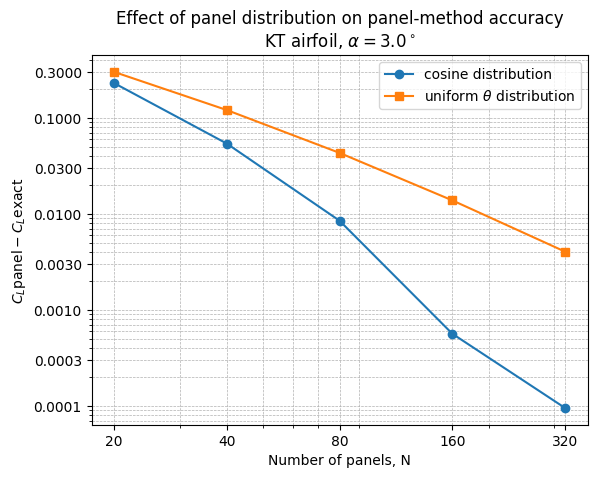

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sys

# Make sure we can import dpan.py
sys.path.append("/content")
from dpan import dpan   # provided panel method


# ==========================================================
# 1) KT generator with selectable theta-distribution
# ==========================================================
def ktreff_dist(alpha, eps, beta, tau, n, distribution="cosine"):
    """
    Kármán–Trefftz airfoil with either cosine or uniform theta distribution.

    distribution: "cosine" (clustered near LE/TE) or "uniform" (even in theta)
    """
    pi = np.pi
    i = complex(0.0, 1.0)
    p = 2.0 - tau/pi
    b = 0.25 * ((1.0 + eps)**p - eps**p) / (1.0 + eps)**p
    a = b * (1.0 + eps) / np.cos(beta)

    # --- theta distribution on the circle ---
    lis = np.append(np.arange(0, 1, 1/n), 1)  # 0..1, n+1 points

    if distribution == "cosine":
        # same as earlier KT code (more points near LE & TE)
        theta = 2.0*pi - beta - pi*(1.0 - np.cos(pi*lis))
    elif distribution == "uniform":
        # uniform spacing in theta
        theta = 2.0*pi - beta - 2.0*pi*lis
    else:
        raise ValueError("distribution must be 'cosine' or 'uniform'")

    # --- circle -> KT mapping (same as before) ---
    zbar = a*np.cos(theta) - b*eps + i*(a*np.sin(theta) + a*np.sin(beta))
    zp = (zbar + b)**p
    zm = (zbar - b)**p
    z = 2.0*b*(zp + zm)/(zp - zm)
    dzdzbar = (8.0*b**2*p*(zp*zm))/((zbar**2 - b**2)*(zp - zm)**2)

    x = z.real + 1.0 - 2.0*b   # shift so 0 < x < 1
    y = z.imag

    # --- flow, for "exact" Cl from mapping ---
    dphidzbar = (np.exp(-i*alpha)*(1.0 - np.exp(i*2.0*(alpha - theta)))
                 + i*2.0*np.sin(alpha + beta)*np.exp(-i*theta))
    dphidz = dphidzbar / dzdzbar
    Uinf = p/2.0
    Cp = 1.0 - dphidz * dphidz.conjugate() / Uinf**2
    Cl = 8.0*pi*a*np.sin(alpha + beta)/Uinf

    return x, y, Cp, Cl


# ==========================================================
# 2) Exact Cl at alpha = 3° (from conformal mapping)
# ==========================================================
alpha_deg = 3.0
alpha = np.deg2rad(alpha_deg)

eps   = 0.08
beta  = 0.07
tau   = 0.2

# any fine distribution is fine for Cl_exact (it is analytic)
x_ref, y_ref, Cp_ref, Cl_exact = ktreff_dist(alpha, eps, beta, tau,
                                             n=800, distribution="cosine")
Cl_exact = float(np.real(np.atleast_1d(Cl_exact).mean()))
print(f"Exact (conformal mapping) Cl at {alpha_deg:.1f}°: {Cl_exact:.6f}")

# ==========================================================
# 3) Panel-method Cl for different N and distributions
# ==========================================================
N_list = np.array([20, 40, 80, 160, 320])

errors_cos = []
errors_uni = []

for N in N_list:
    # --- cosine-distribution geometry (N panels -> N+1 points) ---
    x_c, y_c, _, _ = ktreff_dist(alpha, eps, beta, tau, n=N,
                                 distribution="cosine")
    Cp_pan_c, Cl_pan_c = dpan(alpha, x_c, y_c, n=N)
    Cl_pan_c = float(np.real(np.atleast_1d(Cl_pan_c).mean()))
    errors_cos.append(abs(Cl_pan_c - Cl_exact))

    # --- uniform-theta geometry ---
    x_u, y_u, _, _ = ktreff_dist(alpha, eps, beta, tau, n=N,
                                 distribution="uniform")
    Cp_pan_u, Cl_pan_u = dpan(alpha, x_u, y_u, n=N)
    Cl_pan_u = float(np.real(np.atleast_1d(Cl_pan_u).mean()))
    errors_uni.append(abs(Cl_pan_u - Cl_exact))

errors_cos = np.array(errors_cos, dtype=float)
errors_uni = np.array(errors_uni, dtype=float)

print("\nPanel-method CL errors at alpha = 3°:")
for N, e_c, e_u in zip(N_list, errors_cos, errors_uni):
    print(f"  N = {N:3d}:  cosine error = {e_c:.3e},  uniform-theta error = {e_u:.3e}")

import matplotlib.ticker as mticker

# ==========================================================
# 4) Plot: error vs N for both distributions (clean axes)
# ==========================================================
fig, ax = plt.subplots()

ax.loglog(N_list, errors_cos, "-o", label="cosine distribution")
ax.loglog(N_list, errors_uni, "-s", label=r"uniform $\theta$ distribution")

ax.set_xlabel("Number of panels, N")
ax.set_ylabel(r"$C_L{\mathrm{panel}} - C_L{\mathrm{exact}}$")
ax.set_title("Effect of panel distribution on panel-method accuracy\n"
             f"KT airfoil, $\\alpha = {alpha_deg:.1f}^\\circ$")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

# X ticks = your N values
ax.set_xticks(N_list)
ax.get_xaxis().set_major_formatter(mticker.FormatStrFormatter("%d"))

# Y ticks: fixed, readable set covering your error range
y_ticks = [0.3, 0.1, 0.03, 0.01, 0.003, 0.001, 0.0003, 0.0001]
ax.set_yticks(y_ticks)
ax.get_yaxis().set_major_formatter(mticker.FormatStrFormatter("%.4f"))

ax.legend()
plt.show()


**XFOIL Ready .dat files**

In [21]:
import numpy as np

# ==========================================================
# 1) Assume ktreff(...) already defined earlier in notebook
#    (the same KT generator you've been using)
# ==========================================================

# --- NACA 4-digit generator (thickness added normal to camber line) ---
def naca4_geometry(M, P, TT, x):
    """
    Generate NACA 4-digit airfoil on x (0..1).
    M: max camber (%)  -> first digit
    P: camber location (tenths of chord) -> second digit
    TT: thickness (%)  -> last two digits
    Returns xu, yu, xl, yl.
    """
    m = M / 100.0
    p = P / 10.0
    t = TT / 100.0

    # thickness distribution
    a0, a1, a2, a3, a4 = 0.2969, -0.1260, -0.3516, 0.2843, -0.1015
    yt = 5 * t * (a0*np.sqrt(x) + a1*x + a2*x**2 + a3*x**3 + a4*x**4)

    # camber line and slope
    yc = np.zeros_like(x)
    dyc_dx = np.zeros_like(x)

    if m > 0 and p > 0:
        idx1 = x < p
        idx2 = x >= p

        yc[idx1] = m / p**2 * (2*p*x[idx1] - x[idx1]**2)
        dyc_dx[idx1] = 2*m / p**2 * (p - x[idx1])

        yc[idx2] = m / (1 - p)**2 * ((1 - 2*p) + 2*p*x[idx2] - x[idx2]**2)
        dyc_dx[idx2] = 2*m / (1 - p)**2 * (p - x[idx2])

    theta = np.arctan(dyc_dx)

    xu = x - yt*np.sin(theta)
    yu = yc + yt*np.cos(theta)
    xl = x + yt*np.sin(theta)
    yl = yc - yt*np.cos(theta)

    return xu, yu, xl, yl


# ==========================================================
# 2) Generate KT airfoil geometry (alpha=0 for pure geometry)
# ==========================================================
eps   = 0.08
beta  = 0.07
tau   = 0.2
alpha = 0.0
n_geom = 400

x_kt_raw, y_kt_raw, _, _ = ktreff(alpha, eps, beta, tau, n_geom)

# Split into upper / lower, interpolate to a clean x-grid
upper_mask = y_kt_raw >= 0.0
lower_mask = y_kt_raw <= 0.0

x_u, y_u = x_kt_raw[upper_mask], y_kt_raw[upper_mask]
x_l, y_l = x_kt_raw[lower_mask], y_kt_raw[lower_mask]

order_u = np.argsort(x_u)
order_l = np.argsort(x_l)

x_u, y_u = x_u[order_u], y_u[order_u]
x_l, y_l = x_l[order_l], y_l[order_l]

x_c = np.linspace(0.0, 1.0, 400)
y_u_i = np.interp(x_c, x_u, y_u)
y_l_i = np.interp(x_c, x_l, y_l)

# Build closed loop: TE upper (x≈1) → LE (0) → TE lower (1)
x_kt_loop = np.concatenate([x_c[::-1], x_c[1:]])  # avoid duplicate LE point
y_kt_loop = np.concatenate([y_u_i[::-1], y_l_i[1:]])

# ==========================================================
# 3) Generate NACA 3514 geometry on same style of loop
# ==========================================================
M, P, TT = 3, 5, 14   # NACA 3514

xu_n, yu_n, xl_n, yl_n = naca4_geometry(M, P, TT, x_c)

x_naca_loop = np.concatenate([xu_n[::-1], xl_n[1:]])
y_naca_loop = np.concatenate([yu_n[::-1], yl_n[1:]])

# ==========================================================
# 4) Write XFOIL .dat files
# ==========================================================
def write_xfoil_dat(filename, name, x, y):
    with open(filename, "w") as f:
        f.write(name + "\n")            # first line: airfoil name
        for xi, yi in zip(x, y):
            f.write(f"{xi:.6f} {yi:.6f}\n")

write_xfoil_dat("KT_airfoil_XFOIL.dat",
                "KT_e0.08_b0.07_tau0.2", x_kt_loop, y_kt_loop)

write_xfoil_dat("NACA3514_XFOIL.dat",
                "NACA 3514", x_naca_loop, y_naca_loop)

print("Wrote files:")
print("  - KT_airfoil_XFOIL.dat")
print("  - NACA3514_XFOIL.dat")

# ==========================================================
# 5) (Optional) download to your machine from Colab
# ==========================================================
# from google.colab import files
# files.download("KT_airfoil_XFOIL.dat")
# files.download("NACA3514_XFOIL.dat")


Wrote files:
  - KT_airfoil_XFOIL.dat
  - NACA3514_XFOIL.dat
